In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\nigeria_messy_sales_dataset.csv")

In [3]:
df = df.reset_index(drop=True)

In [4]:
df.head(5)#.to_clipboard(index=False)

,Customer Name,State,Product,Units Sold,Unit Price,Total Sale,Sale Date,Sales Channel,Order ID
0,NaN,rivers,KEYBOARD,NaN,NaN,NaN,2025-04-27,Online,NaN
1,Allison Hill,Lagos,Headphones,NaN,267992.94,NaN,2024-03-15,Wholesale,4c636e95-025f-4543-8997-623ae0723d96
2,Noah Rhodes,Anambra,Keyboard,NaN,42364.41,NaN,2024-12-10,NaN,edaf3766-1b78-4ede-9a4f-fc0c9165f2ed
3,Angie Henderson,Delta,Keyboard,NaN,279444.94,NaN,2024-04-05,NaN,74503887-48d9-4846-95c5-51fcfba57cc8
4,Daniel Wagner,Delta,Tablet,NaN,95899.74,NaN,2025-01-12,NaN,8639bd41-8b15-4d94-a42d-0cd7fd359f6a


In [5]:
df.tail(5).to_clipboard(index=False)

In [6]:
df.shape

(550, 9)

In [7]:
df.columns

Index(['Customer Name', 'State', 'Product', 'Units Sold', 'Unit Price',
       'Total Sale', 'Sale Date', 'Sales Channel', 'Order ID'],
      dtype='object')

In [8]:
# Remove extra spaces and replace ' ' into _ and lower case all letters
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

In [9]:
df.dtypes

customer_name     object
state             object
product           object
units_sold       float64
unit_price       float64
total_sale       float64
sale_date         object
sales_channel     object
order_id          object
dtype: object

In [10]:
df.isna().sum()

customer_name     43
state              0
product            0
units_sold       395
unit_price        55
total_sale       413
sale_date          0
sales_channel    106
order_id          40
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

## **Data Cleaning (filling none values and others work)**

In [12]:
#removing all fake null from object column
na_values = ["na", "n/a", "none", "null", "", "nan"]
for i in df.columns:
    if df[i].dtypes == "object":
        df[i] = df[i].replace(na_values, np.nan)

In [13]:
#removing all fake null from float column
na_values = ["na", "n/a", "none", "null", "", "nan"]
for i in df.columns:
    if df[i].dtypes == "float":
        df[i] = df[i].replace(na_values, np.nan)
        

In [14]:
#filling correct values of total sale
df['total_sale'] = df['units_sold'] * df['unit_price']

In [15]:
#removing null rows of these columns ['units_sold','unit_price','total_sale','order_id']
df = df.dropna(subset=['units_sold','unit_price','total_sale','order_id'])

In [16]:
#filling unknown and mode values at null in customer name and sales channel
df['customer_name'] = df['customer_name'].fillna('Unknown')
df['sales_channel'] = df['sales_channel'].fillna(df['sales_channel'].mode()[0])

In [17]:
#now cheking null values
df.isna().sum()

customer_name    0
state            0
product          0
units_sold       0
unit_price       0
total_sale       0
sale_date        0
sales_channel    0
order_id         0
dtype: int64

In [18]:
#total rows and column
df.shape

(129, 9)

In [19]:
#data type checking
df.dtypes

customer_name     object
state             object
product           object
units_sold       float64
unit_price       float64
total_sale       float64
sale_date         object
sales_channel     object
order_id          object
dtype: object

In [20]:
#checking unique values of product column and found that some are repeating by lower and upper case
df['product'].unique()

array(['Tablet', 'Laptop', 'Headphones', 'LAPTOP', 'Charger', 'Monitor',
       'Camera', 'MONITOR', 'Phone', 'Keyboard', 'TABLET', 'KEYBOARD',
       'HEADPHONES', 'CHARGER'], dtype=object)

In [21]:
#correcting product columns by using dict
# Sab lowercase kar do pehle (representation ke liye yaha tak v sahi h normally)

df['product'] = df['product'].str.lower().str.strip()

# Phir proper mapping (optional but bahut clean dikhega aur dashboard sab m acha work krega)
product_mapping = {
    'laptop': 'Laptop',
    'tablet': 'Tablet',
    'headphones': 'Headphones',
    'charger': 'Charger',
    'monitor': 'Monitor',
    'camera': 'Camera',
    'phone': 'Smartphone',
    'keyboard': 'Keyboard'
}

df['product'] = df['product'].map(product_mapping).fillna(df['product'].str.title())

In [22]:
#again checking product column and found that all are right
df['product'].unique()

array(['Tablet', 'Laptop', 'Headphones', 'Charger', 'Monitor', 'Camera',
       'Smartphone', 'Keyboard'], dtype=object)

In [23]:
#checking unique values of state column and found that some are repeating by lower and upper case
df['state'].unique()

array(['Rivers', 'Abuja', 'Lagos', 'Katsina', 'lagos', 'Imo', 'Niger',
       'Ekiti', 'Anambra', 'Oyo', 'Benue', 'Kaduna', 'Kano', 'katsina',
       'Enugu', 'Plateau', 'Delta', 'kaduna', 'niger', 'Bauchi', 'delta',
       'Cross River', 'sokoto', 'plateau', 'rivers', 'Borno', 'Sokoto',
       'osun', 'Osun', 'benue', 'imo', 'borno', 'abuja'], dtype=object)

In [24]:
#correcting state columns by using dict
# Sab lowercase + extra spaces hatao
df['state'] = df['state'].str.lower().str.strip()

# Proper Nigerian state names mein convert kar do
state_mapping = {
    'rivers': 'Rivers',
    'abuja': 'Abuja',
    'lagos': 'Lagos',
    'katsina': 'Katsina',
    'imo': 'Imo',
    'niger': 'Niger',
    'ekiti': 'Ekiti',
    'anambra': 'Anambra',
    'oyo': 'Oyo',
    'benue': 'Benue',
    'kaduna': 'Kaduna',
    'kano': 'Kano',
    'enugu': 'Enugu',
    'plateau': 'Plateau',
    'delta': 'Delta',
    'bauchi': 'Bauchi',
    'cross river': 'Cross River',
    'sokoto': 'Sokoto',
    'osun': 'Osun',
    'borno': 'Borno'
}

df['state'] = df['state'].map(state_mapping).fillna(df['state'].str.title())

In [25]:
#again checking state column and found all are right
df['state'].unique()

array(['Rivers', 'Abuja', 'Lagos', 'Katsina', 'Imo', 'Niger', 'Ekiti',
       'Anambra', 'Oyo', 'Benue', 'Kaduna', 'Kano', 'Enugu', 'Plateau',
       'Delta', 'Bauchi', 'Cross River', 'Sokoto', 'Borno', 'Osun'],
      dtype=object)

In [26]:
df['state'].nunique()

20

In [27]:
#now correcting data type of certain columns which should be changed
df['units_sold'] = df['units_sold'].astype('int64')

In [28]:
df['units_sold'].dtypes

dtype('int64')

In [29]:
#converting sale date column in standard datetime formate
df['sale_date'] = pd.to_datetime(df['sale_date'], dayfirst=True, errors='coerce')

In [30]:
#sorting date column in startig to ending column
df = df.sort_values(by='sale_date')

In [31]:
#now checking top 10 of sale date
df['sale_date'].head(10)

453   2023-01-11
544   2023-02-12
368   2023-04-10
113   2023-07-11
418   2023-07-12
502   2023-10-11
12    2023-10-11
271   2023-11-10
455   2023-12-08
128   2023-12-09
Name: sale_date, dtype: datetime64[ns]

In [32]:
#after converting in datetime formate checking null values
print("Null dates after conversion:", df['sale_date'].isna().sum())

Null dates after conversion: 77


In [33]:
#iska mtlb date column m jo NaT (mssing date) usko date m month wise jo pahle 
#se minimum date hoga usse replace kr dega
df['sale_date'] = df['sale_date'].fillna(df['sale_date'].min())

In [34]:
#after filing null values in sale date columns, checking null values
df['sale_date'].isna().sum()

np.int64(0)

In [35]:
#now cleaning sales channel column
df['sales_channel'] = df['sales_channel'].str.strip().str.title()

In [36]:
df['sales_channel'].isna().sum()

np.int64(0)

In [37]:
df['customer_name'].isna().sum()

np.int64(0)

In [38]:
df['customer_name'].nunique()

124

In [39]:
df.shape

(129, 9)

## **Final Result After Cleaning**

In [40]:
df.head(10)

,customer_name,state,product,units_sold,unit_price,total_sale,sale_date,sales_channel,order_id
453,Jeffrey Mills,Enugu,Monitor,24,2411.96,57887.04,2023-01-11,Online,7f14eafa-29f0-4f7c-82e7-df89b3957a98
544,Mr. Justin Green III,Sokoto,Keyboard,65,206948.51,13451653.15,2023-02-12,Online,ec93e596-2b01-4723-8cf6-97a57603c36c
368,David Thompson,Sokoto,Headphones,44,99413.77,4374205.88,2023-04-10,Retail,17d821b8-bb93-4d40-98df-f535c62dbaea
113,Richard Henson,Kano,Monitor,44,70234.55,3090320.20,2023-07-11,Retail,abe42e7d-b96c-4163-966b-e275c2fe8954
418,Chad Scott,Ekiti,Keyboard,63,222505.09,14017820.67,2023-07-12,Online,e03635fc-a88d-4108-98d9-94b8d90f74e9
502,Taylor Carlson,Borno,Laptop,19,143063.53,2718207.07,2023-10-11,Direct,d872f72e-e5b4-41ae-bb41-c943ebd8a3b1
12,Jamie Arnold,Lagos,Tablet,43,147209.07,6329990.01,2023-10-11,Wholesale,a383889a-db2c-4ac8-9c67-83932ced3c0d
271,Isaiah Avila,Oyo,Tablet,69,218922.21,15105632.49,2023-11-10,Wholesale,adf75924-c5b8-486b-b68b-4f7e64215e66
455,Unknown,Abuja,Keyboard,8,189395.14,1515161.12,2023-12-08,Retail,425e0259-b884-46d2-928f-cf68c871d7b3
128,Victor Baker,Lagos,Keyboard,56,86529.89,4845673.84,2023-12-09,Online,340029c3-ea11-405b-91fa-cefad6f89f7a


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129 entries, 453 to 541
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_name  129 non-null    object        
 1   state          129 non-null    object        
 2   product        129 non-null    object        
 3   units_sold     129 non-null    int64         
 4   unit_price     129 non-null    float64       
 5   total_sale     129 non-null    float64       
 6   sale_date      129 non-null    datetime64[ns]
 7   sales_channel  129 non-null    object        
 8   order_id       129 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 10.1+ KB


In [42]:
df.describe()

,units_sold,unit_price,total_sale,sale_date
count,129.000000,129.000000,1.290000e+02,129
mean,46.658915,149670.847752,7.000783e+06,2023-09-01 06:19:32.093023232
min,1.000000,2411.960000,5.788704e+04,2023-01-11 00:00:00
25%,24.000000,70234.550000,1.788402e+06,2023-01-11 00:00:00
50%,48.000000,150794.940000,5.049848e+06,2023-01-11 00:00:00
75%,67.000000,219965.280000,1.119981e+07,2024-04-09 00:00:00
max,98.000000,298048.290000,2.873459e+07,2025-12-05 00:00:00
std,27.085079,87436.731531,6.252760e+06,NaN


## **Creating New Column for EDA and Feature Engineering**

In [43]:
#Separating month date from sale month column
df['sale_month'] = df['sale_date'].dt.month

In [44]:
#Separating year date from sale month column
df['sale_year'] = df['sale_date'].dt.year

In [45]:
#Separating year date from sale month column
df['sale_day'] = df['sale_date'].dt.day_name()

## **EDA**

In [46]:
#Top 5 selling product
df.groupby('product')['units_sold'].sum().sort_values(ascending=False).head()

product
Keyboard      1156
Headphones    1006
Tablet         967
Monitor        768
Smartphone     724
Name: units_sold, dtype: int64

In [47]:
#Heighest to Lowest selling by state
df.groupby('state')['total_sale'].sum().sort_values(ascending=False)

state
Benue          83651542.02
Rivers         80846826.76
Delta          70752955.06
Kano           66430447.61
Imo            63466338.88
Plateau        61414056.17
Kaduna         58834730.64
Niger          54765574.51
Sokoto         44669534.61
Lagos          44548407.02
Katsina        36094558.16
Bauchi         33982869.24
Cross River    33914235.67
Abuja          33383113.98
Enugu          30665019.02
Oyo            28967495.85
Osun           26309925.52
Borno          23286853.24
Ekiti          16016820.99
Anambra        11099688.88
Name: total_sale, dtype: float64

In [48]:
#Heighest selling amount by sale  channel
df.groupby('sales_channel')['total_sale'].sum()

sales_channel
Direct       1.484506e+08
Online       3.936048e+08
Retail       1.956314e+08
Wholesale    1.654142e+08
Name: total_sale, dtype: float64

In [49]:
#Monthly sales trend
df.groupby('sale_month')['total_sale'].sum()

sale_month
1     5.751074e+08
2     2.186207e+07
3     2.607519e+07
4     4.844031e+07
5     4.940797e+07
6     3.193037e+07
7     2.967940e+07
9     2.209138e+07
10    4.785896e+07
11    3.113382e+07
12    1.951418e+07
Name: total_sale, dtype: float64

## **Visualization By (Matplotlib and Seaborn)**

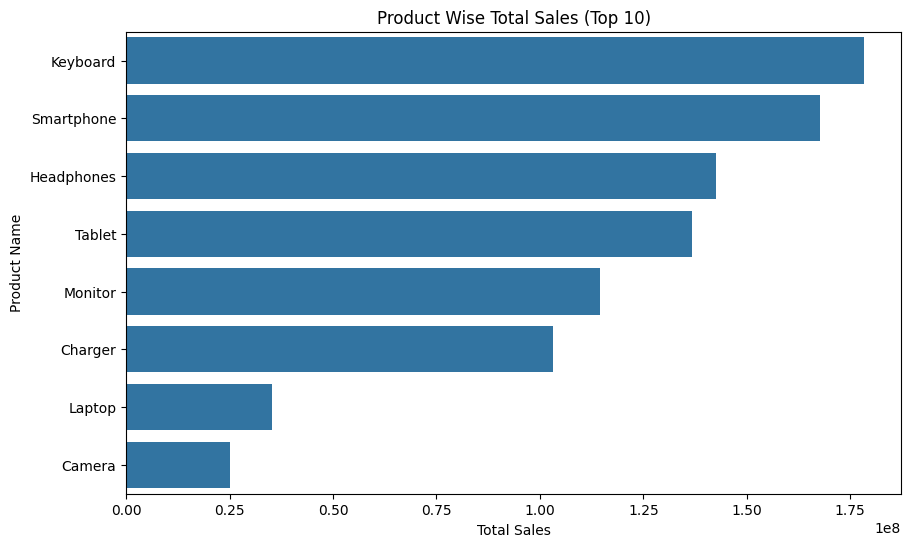

In [50]:
top_products = df.groupby('product')['total_sale'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Product Wise Total Sales (Top 10)")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()

## **1. What the bar chart shows.?**

This bar chart shows the top 10 products that generated the highest total sales.
Each bar represents how much money each product earned.

## **2. Analysis**

*. Keyboard has the highest total sales among all products.


*. Smartphones are the second-highest revenue generating product.


*. Headphones, Tablet, and Monitor are in the mid-range, showing good sales performance.


*. Chargers and Laptops also contribute a moderate amount of revenue.


*. Camera is the lowest among the top 10, meaning it sold less compared to others.

## **3. Insights**

*.Keyboard and Smartphone are the most popular products, generating the maximum revenue.
  ----> The company should keep them in high stock and promote them more.


*.Mid-range products like Tablet and Monitor show steady demand, indicating consistent customer interest.


*.Low-performing product (Camera) may need better marketing, discount offers, or review of pricing strategy.


*.The variety of top-selling items suggests that customers buy both accessories and main devices, meaning the product mix is healthy.

## **4. Final Conclusion**

The product-wise sales analysis shows that Keyboard and Smartphone are the top revenue drivers, while products like Camera need attention to improve sales.
This information can help the business in inventory planning, pricing decisions, and targeted marketing.

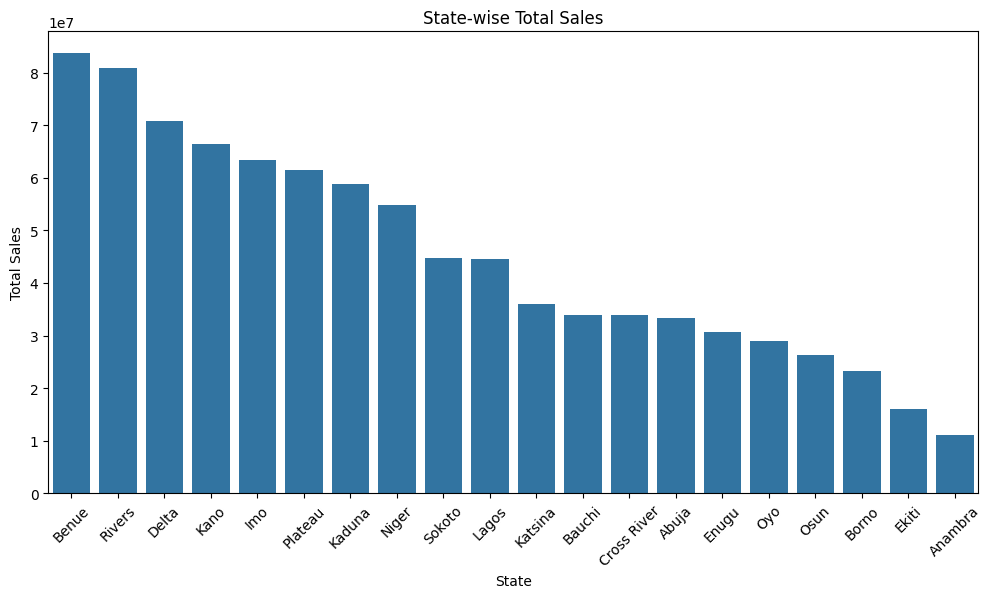

In [51]:
state_sales = df.groupby('state')['total_sale'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=state_sales.index, y=state_sales.values)
plt.title("State-wise Total Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## **1. What the chart shows.?**

This bar chart shows how much total sales each state generated.
States at the top earned more revenue, while states at the bottom earned less.

## **2. Analysis**

*. Benue recorded the highest total sales among all states.

*. Rivers and Osun also have strong sales performance, coming right after Benue.

*. Delta, Kano, Imo, Plateau, Kaduna, Niger, Sokoto show moderate sales levels.

*. States like Ikiti and Anambra are at the lowest end of the chart, indicating lower sales.

## **3. Insights**

*. Benue is the strongest market for the company.
    ----> The business can focus more here to maintain strong revenue.

*. Rivers and Delta also show high customer demand, so they are potential growth areas.

*. Mid-performing states (Kano, Imo, Plateau, Kaduna) show consistent demand.
    ----> These states can be targeted for marketing campaigns and product promotions.

*. Low-performing states (Ikiti, Anambra) may need:

  --->  better distribution

  --->  regional marketing

  --->  price adjustments

  --->  partnership with local sellers

*. State-wise sales variation helps the company plan regional strategies,
like where to increase supply and where to improve visibility.

## **4. Final Conclusion**

The analysis shows that Benue, Rivers, and Delta are the top-performing states, contributing the highest sales.
However, states like Ikiti and Anambra need more attention to improve sales.

This insight helps the business focus on strong markets for growth and improve strategies in low-performing regions.

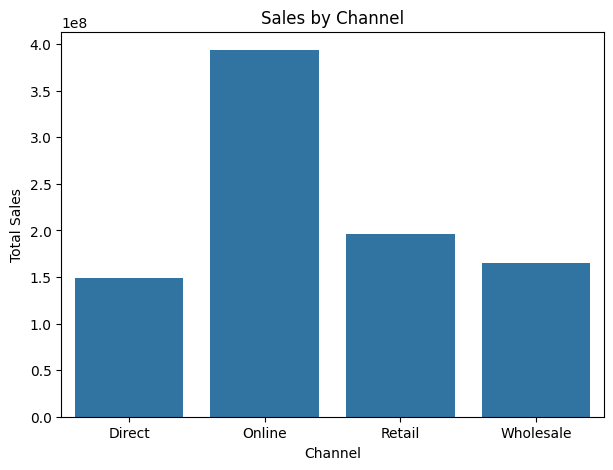

In [52]:
channel_sales = df.groupby('sales_channel')['total_sale'].sum()

plt.figure(figsize=(7,5))
sns.barplot(x=channel_sales.index, y=channel_sales.values)
plt.title("Sales by Channel")
plt.xlabel("Channel")
plt.ylabel("Total Sales")
plt.show()

## **1. What the chart shows.?**

This bar chart shows how much total sales were generated from each sales channel:
Online, Retail, Direct, and Wholesale.
The length of each bar represents the total revenue from that channel.

## **2. Analysis**

*. Online channel has the highest total sales among all channels.

*. Retail is in second place with a good amount of sales.

*. Wholesale contributes moderate revenue.

*. Direct channel has the lowest sales compared to the other channels.

## **3. Insights**

*. Online is the top-performing channel, meaning customers prefer buying through online platforms.
  ---> The business should continue investing in online marketing and logistics.


*. Retail also shows strong performance,
  ---> This means physical store sales are still significant and should be supported.


*. Wholesale has average contribution,
  ---> This segment can grow with partnerships and bulk deals.


*. The Direct channel is the weakest,
  ---> This channel may need promotional offers, better customer engagement, or improved reach.


*. Having multiple strong channels (Online + Retail) reduces dependency on only one source,
  ---> Making the business more stable and diversified.

## **4. Final Conclusion**

The sales analysis by channel shows that Online and Retail are the highest revenue-generating channels, while Direct sales are the lowest.
This insight can help the business focus more on high-performing channels and improve strategies for low-performing ones.

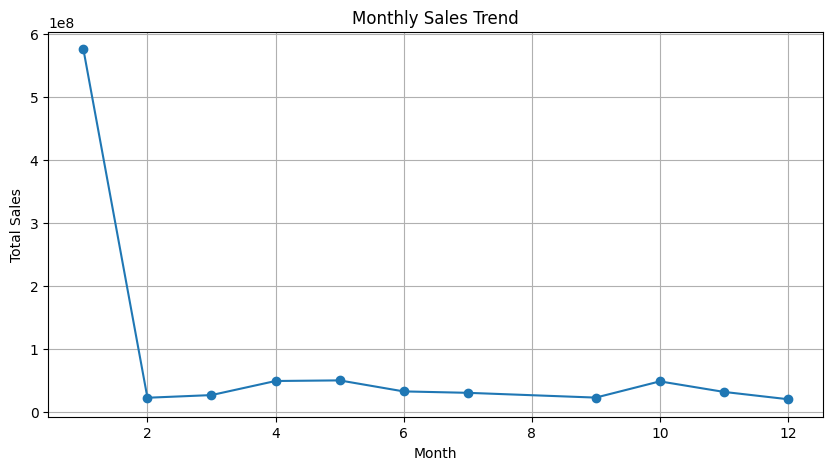

In [53]:
monthly_sales = df.groupby('sale_month')['total_sale'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

## **1. What the chart shows.?**

This line graph shows total sales for each month from Month 1 to Month 12.
The line helps us understand whether sales are increasing, decreasing, or staying stable throughout the year.

## **2. Analysis**

*. Month 1 has very high sales compared to the rest of the months.

*. After Month 1, sales continuously decrease till Month 6.

*. From Month 7 to Month 12, sales remain low and almost flat, showing no major improvement.

*. There is no peak after Month 1, meaning the later months did not perform well.
    
## **3. Insights**

*. Strong start of the year.
   Month 1 performed exceptionally well, possibly due to seasonal demand, offers, or new product launches.

*. Sharp decline after Month 1.
   The business could not maintain the momentum.
   This may indicate reduced marketing, losing customers, or seasonal drop.

*. Very low performance in mid-year (Months 5–9).
   These months can be targeted for improvement with campaigns or discounts.

*. Last quarter (Months 10–12) did not show recovery.
   Normally businesses recover in Q4, but here sales stayed low.
   This suggests deeper issues like less demand, stock problems, or poor promotions.

*. Overall yearly trend is downward
   The company needs to investigate why sales dropped and didn't pick up again.

## **4. Final Conclusion**

The monthly trend indicates that the business had an excellent start in Month 1, but sales declined continuously and remained low for the rest of the year.
This pattern highlights the importance of identifying factors that led to high sales early on and fixing the causes behind the sharp drop in later months.

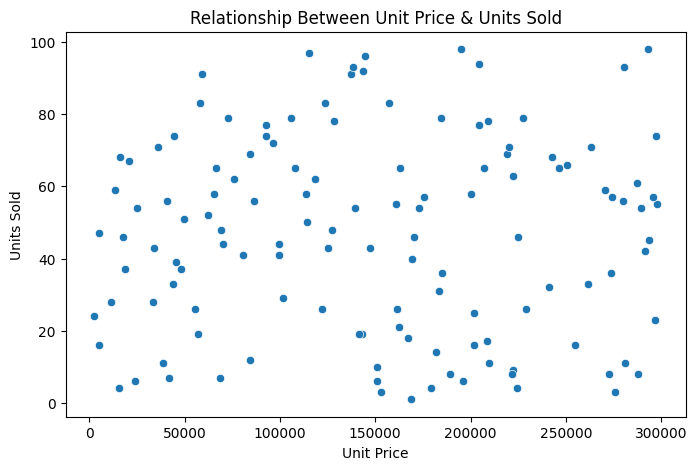

In [54]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='unit_price', y='units_sold', data=df)
plt.title("Relationship Between Unit Price & Units Sold")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")
plt.show()

## **1. What this graph shows**

     This scatter plot compares:
     X-axis: Unit Price (how much the product costs)
     Y-axis: Units Sold (how many pieces were sold)

Each blue dot = one product.

## **2. Analysis**

*.The dots are spread everywhere.
*.There is no clear pattern.
*.Some expensive products sold a lot.
*.Some cheap products sold less.
*.Some cheap products sold more.
*.Some expensive products sold less.

So overall:

 Price is not controlling the sales.
 Sales don’t depend on price.

## **3. Insights**

Insight 1: No strong relationship

The graph shows no clear relation between price and units sold.

Price ↑ does NOT mean sales ↓.
Price ↓ does NOT mean sales ↑.

Insight 2: High price items also sell well

Some expensive products still have high sales.This means customers buy them because of:

    *.Quality
    *.Brand
    *.Category

Not just the price.

Insight 3: Low price doesn’t guarantee high sales

Some cheap products sold less.
So: Cheap price ≠ good sales

Insight 4: Pricing is flexible

Because sales don’t depend much on price:

*.The company can increase price a little
*.and sales will not drop much

Good for profit.

## **4. Final Conclusion**

“There is no strong relationship between product price and units sold. Customers are not buying only based on price. So the business can change prices without a big impact on sales.”

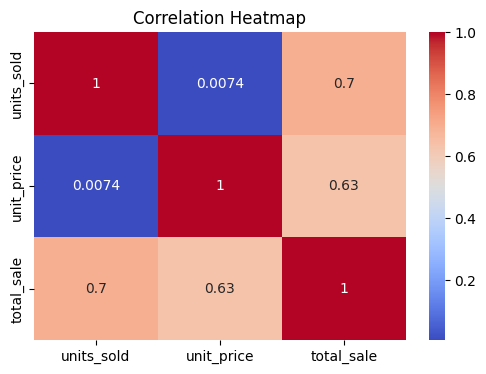

In [55]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['units_sold','unit_price','total_sale']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## **Correlation Heatmap**

This heatmap shows how strongly two numbers are connected.

*.Value close to 1 → strong relationship
*.Value close to 0 → no relationship
*.Value close to –1 → opposite relationship

## **1. What this heatmap shows.?**

The heatmap compares three things:

*.total_sale
*.unit_price
*.units_sold

And tells how much they are connected.

## **2. Analysis**

*.total_sale & units_sold = 0.70 (Strong positive)

More units sold → total sale increases
(and it makes sense)

If you sell more quantity, total money increases.

*.total_sale & unit_price = 0.63 (Good positive)

If the price is higher, total sale also increases.

Why?
Because expensive items bring more money even if quantity is small.

High price → more revenue

*.units_sold & unit_price = 0.007 (Almost zero)

Price does NOT affect units sold.

Same result as scatter plot:

People are buying products not because of price.

## **3. Insights**

Insight 1: Units Sold strongly drives Total Sales

More pieces sold = more money earned.

Insight 2: Higher price also increases Total Sales

Because expensive products give more revenue.

Insight 3: Price has almost NO impact on Units Sold

Sales are stable even if prices change.

## **4. Final Conclusion**

“This heatmap shows that total sales depend on both price and units sold. But units sold do not depend on price. Customers are not very price-sensitive.”

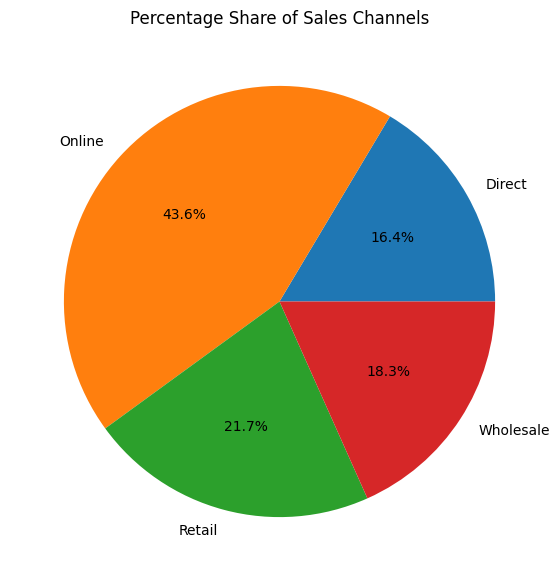

In [56]:
plt.figure(figsize=(7,7))
plt.pie(channel_sales.values, labels=channel_sales.index, autopct='%1.1f%%')
plt.title("Percentage Share of Sales Channels")
plt.show()

## **Pie Chart – Percentage Share of Sales Channels**

This pie chart shows how much each sales channel contributes to total sales in percentage.

## **1. What the chart shows.?**

There are 4 sales channels:

*.Online
*.Retail
*.Wholesale
*.Direct

Each slice shows their share in total revenue.

## **2. Analysis (Percentage Share)**

*. Online – 43.6% (Highest share)

Almost half of the total sales come from online channel.

Online is the strongest and most successful sales channel.

*. Retail – 21.7%

Retail stores contribute a good amount.

Second-highest channel after Online.

*. Wholesale – 18.3%

Wholesale contributes moderately.

Stable but not very high.

*. Direct – 16.4% (Lowest)

Direct sales (face-to-face, company reps) have the smallest share.

Not performing as well as other channels.

## **3. Insights**

Insight 1: Online channel dominates sales

Online contributes the largest portion (43.6%).
This means customers prefer to buy online.

Insight 2: Retail is the second-most important channel

Retail contributes 21.7% — showing good performance.

Insight 3: Wholesale and Direct have smaller shares

Both are below 20%, meaning:

They may need improvement

Marketing or promotions might increase sales here

## **4. Final Conclusion**

“Most sales come from the Online channel. Retail is in second place. Wholesale and Direct channels have lower contribution.”

In [57]:
!jupyter nbconvert --to html "Nigerian_sales_dataset.ipynb"

[NbConvertApp] Converting notebook Nigerian_sales_dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 596498 bytes to Nigerian_sales_dataset.html
